In [1]:
# IMPORTS
# pip install ucimlrepo --> execute no terminal para baixar o dataset do repositório UCI Machine Learning Repository

import torch
import torch.nn as nn
import torch.optim as optim
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# CARREGAMENTO DOS DADOS (UCI ID: 697)

print("Buscando dados na UCI...")
dataset = fetch_ucirepo(id=697) 
X = dataset.data.features 
y = dataset.data.targets 

# Converter o alvo (Dropout, Enrolled, Graduate) em números (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

print(pd.Series(y_encoded).value_counts())

Buscando dados na UCI...
2    2209
0    1421
1     794
Name: count, dtype: int64


In [3]:
# DIVISÃO DO TREINAMENTO (Treino, Validação e Teste)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Converter para Tensores do PyTorch
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [4]:
# definição da arquitetura da rede neural

class StudentNet(nn.Module):
    def __init__(self, input_size):
        super(StudentNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3) # 3 classes de saída
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) 
        return x

model = StudentNet(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# treinamento do modelo

# Loop de Treino e Validação
epochs = 50
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Validação (para checar Generalização/Overfitting)
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
    
    train_losses.append(running_loss/len(train_loader))
    val_losses.append(v_loss/len(val_loader))
    
    if (epoch+1) % 10 == 0:
        print(f"Época {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f}")

Época 10/50 - Train Loss: 0.4869 - Val Loss: 0.5971
Época 20/50 - Train Loss: 0.3997 - Val Loss: 0.6630
Época 30/50 - Train Loss: 0.3300 - Val Loss: 0.7674
Época 40/50 - Train Loss: 0.2836 - Val Loss: 0.8744
Época 50/50 - Train Loss: 0.2384 - Val Loss: 1.0493


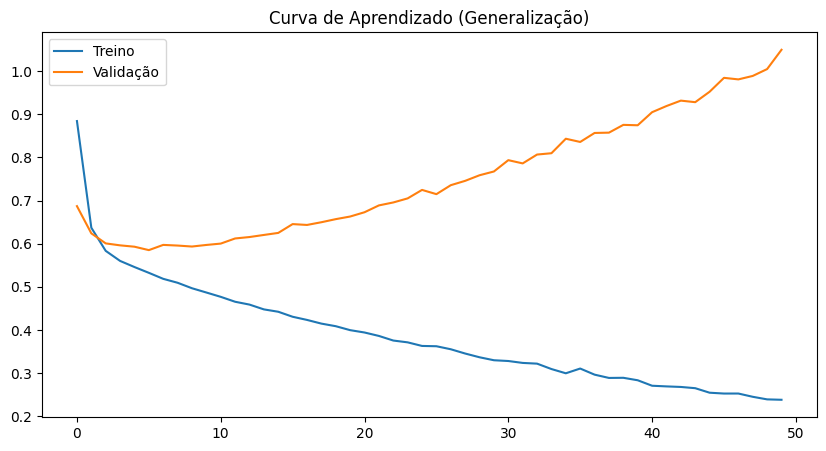

In [6]:
# avaliação do modelo

model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())

# Gráfico de Perda (Loss) 
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title('Curva de Aprendizado (Generalização)')
plt.legend()
plt.show()


--- Relatório de Classificação ---
              precision    recall  f1-score   support

     Dropout       0.76      0.71      0.73       284
    Enrolled       0.33      0.44      0.38       159
    Graduate       0.83      0.77      0.80       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.72      0.69      0.70       885



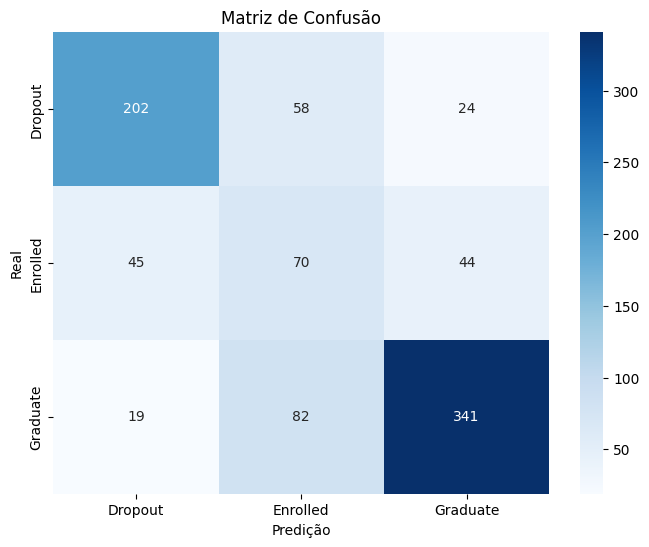

In [7]:
# Relatório de Classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Matriz de Confusão
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()

In [ ]:
# salvamento dos pesos do modelo
caminho_arquivo = "modelo_estudantes.pth"
torch.save(model.state_dict(), caminho_arquivo)
print(f"Modelo salvo com sucesso em: {caminho_arquivo}")

# carregando para testar
modelo_novo = StudentNet(X_train.shape[1]) # Criar instância vazia
modelo_novo.load_state_dict(torch.load(caminho_arquivo))
modelo_novo.eval()

Modelo salvo com sucesso em: modelo_estudantes.pth


StudentNet(
  (fc1): Linear(in_features=36, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)